In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *

In [2]:
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper
from simulate.simulate import *
from omegaconf import OmegaConf
from utils.hydra import *
from datasets.process import *
from scripts.run_model import *

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
%reload_ext autoreload
%autoreload 2

In [5]:
dic = {"s": sample_s,
       "s_imbalanced": sample_s_imbalanced,
       "points": sample_points,
       "diamond": sample_diamond,
       "omega": sample_omega,
       "moons": sample_moons,
       "disk": sample_disk,
       "growth": sample_growth,
       "balance": sample_balance,
       }

In [6]:
############################################################

In [7]:
# ### SETTINGS ###

# dataname = "disk"
# size = 2500
# d = 2 #dummy dimension

# project = "ffm-ipynb"
# adata = process_fake_data(size, d, dic[dataname])
# config = load_config()
# OmegaConf.set_struct(config, False)
# config.pc_dim = d
# config.num_classes = adata.obs['cell_type'].nunique()

# ##################
# config.metric = "cfm"
# config.finsler.use = True
# config.finsler.lamb = 30.0
# config.dummy_kl_weight = 0.3

# config.metric_max_epochs = 2
# config.flow_max_epochs = 2



In [8]:
### SETTINGS ###

# dataname = "growth"
dataname = "balance"
size = 2500
d = 2 #dummy dimension

project = "ffm-ipynb"
adata = process_fake_data(size, d, dic[dataname])
config = load_config()
OmegaConf.set_struct(config, False)
config.pc_dim = d
config.num_classes = adata.obs['cell_type'].nunique()

##################
config.metric = "cfm"
config.finsler.use = True
config.finsler.lamb = 5.0
config.dummy_kl_weight = 0.3

config.classifier_max_epochs = 500
config.metric_max_epochs = 2
config.embed_max_epochs = 2000
config.flow_max_epochs = 2

# config.method = "unbalanced"
# config.reg = 0.01
# config.reg_m = (0.3, float("inf"))

In [9]:
adata

AnnData object with n_obs × n_vars = 2500 × 2
    obs: 'timepoint', 'gene_target', 'cell_type', 'cell_type_one_hot'
    uns: 'std', 'tree'
    obsm: 'X_pca'
    varm: 'PCs'

In [10]:
############################################################

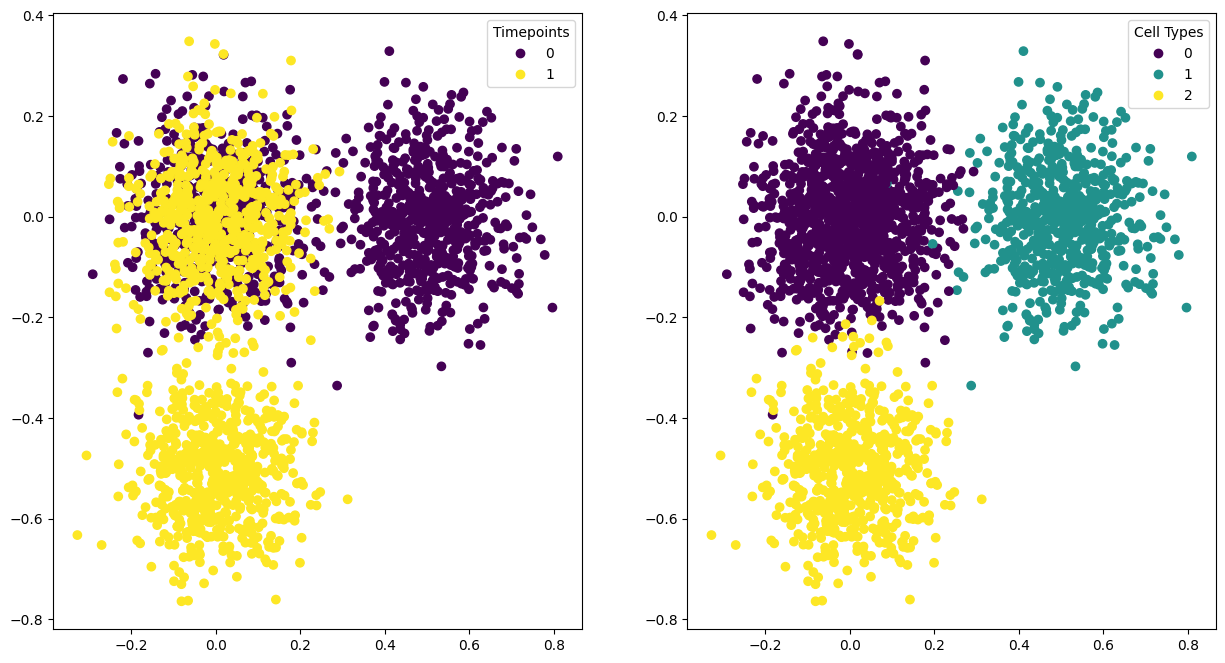

In [11]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(1, 2, figsize = (15, 8))
scatter0 = axs[0].scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
handles, labels = scatter0.legend_elements()
axs[0].legend(handles, labels, title="Timepoints")
scatter1 = axs[1].scatter(samples[:,0], samples[:, 1], c=adata.obs['cell_type_one_hot'].astype(int).tolist())
handles, labels = scatter1.legend_elements()
axs[1].legend(handles, labels, title="Cell Types")

plt.show()

In [12]:
tree = adata.uns['tree']
timepoints = sorted(adata.obs['timepoint'].unique().tolist())
singleton_dataloader = build_singleton_dataloader(config, adata)
paired_dataloader = build_paired_dataloader(config, adata)
classifier_model, metric_model, embed_model, flow_model = run_full_model(config=config,
                                                                         project=project,
                                                                         singleton_dataloader=singleton_dataloader,
                                                                         paired_dataloader=paired_dataloader,
                                                                         timepoints=timepoints,
                                                                         tree=tree)

DEBUG: no fisher rao
DEBUG: trying dumb first loss as scaling for embed
Running phase classifier:.......


wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type           | Params | Mode 
----------------------------------------------------------
0 | classifier_net | SimpleDenseNet | 184    | train
--------

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_ce,█▇▇▇▆▆▅▅▅▅▅▅▄▄▄▄▄▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train_kl,▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▆▇▇███████
train_loss,█▇▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇████
epoch,499
train_ce,0.24593
train_kl,0.69616
train_loss,0.45478
trainer/global_step,499


Running phase metric:.......


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type           | Params | Mode 
--------------------------------------------------------
0 | embed_net    | SimpleEmbedNet | 159 K  | train
1 | geo_net      | SinNet         | 151 K  | train
2 | metric_model | FinslerCFM     | 184    | eval 
  | other params | n/a            | 50     | n/a  
--------------------------------------------------------
310 K     Trainable params
184       Non-trainable params
311 K     Total params
1.244     Total estimated model params size (MB)
26        Modules in train mode
8         Mo

epoch,▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
train_loss_embed,██▆▆▃▂▂▂▂▃▂▂▁▂▁▂▁▁▁▁▁▂▂▂▁▁▁▁▂▂▂▂▃▂▃▂▂▃▂▂
train_loss_geo,█▆▄▃▃▂▂▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▂▂▁▁▁
trainer/global_step,▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇████
epoch,1999
train_loss_embed,0.0365
train_loss_geo,0.05638
trainer/global_step,1999


Running phase flow:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                     | Params | Mode 
-----------------------------------------------------------------
0 | flow_net    | SinNet                   | 150 K  | train
1 | embed_model | FinslerEmbedNetTrainBase | 311 K  | eval 
-----------------------------------------------------------------
150 K     Trainable params
311 K     Non-trainable params
461 K     Total params
1.848     Total estimated model params size (MB)
13        Modules in train mode
35        Modules in eval mode
/home/azweig/miniconda3/envs/spatialen

epoch,▁█
train_loss,▁█
trainer/global_step,▁█
epoch,1
train_loss,11.97115
trainer/global_step,1


In [13]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

/tmp/ipykernel_607743/4230595706.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
/tmp/ipykernel_607743/4230595706.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.arange(y_min, y_max, h))


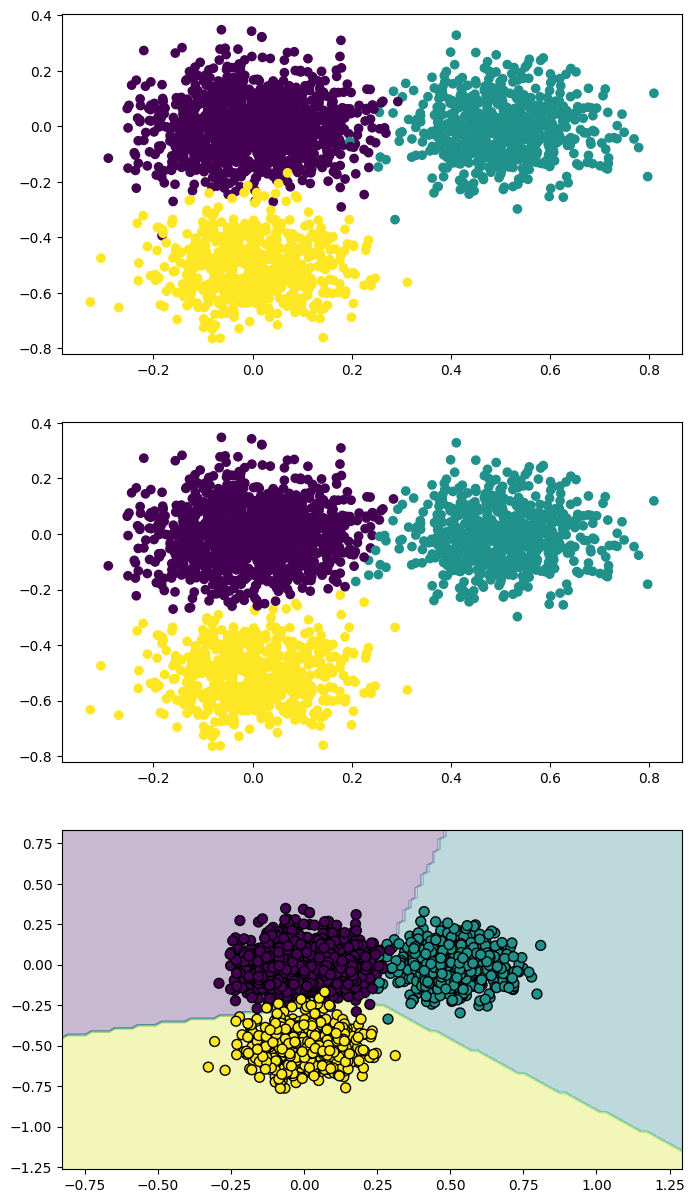

In [14]:
if config.finsler.use:

    X = torch.from_numpy(adata.obsm['X_pca']).float()
    y = torch.from_numpy(adata.obs['cell_type_one_hot'].astype(int).to_numpy()).long()
    y_pred = classifier_model(X, normalize=True).argmax(dim=1)

    fig, axs = plt.subplots(3, figsize = (8,15))
    axs[0].scatter(X[:,0], X[:, 1], c=y)
    axs[1].scatter(X[:,0], X[:, 1], c=y_pred)
    
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02  # Step size for the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.FloatTensor(grid_points)

    with torch.no_grad():
        logits = classifier_model(grid_tensor, normalize=True)
        predictions = torch.argmax(logits, dim=1)

    Z = predictions.cpu().numpy().reshape(xx.shape)
    
    axs[2].contourf(xx, yy, Z, alpha=0.3, cmap='viridis')    
    scatter = axs[2].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=50)

    plt.show()
    

In [15]:
#NOTE: only works for MFM
#NOTE: need to update with normalize code
def visualize_metric(metric_model, samples, grid_steps=30):

    import torch, numpy as np, matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    plt.close('all')

    m = torch.max(torch.abs(samples)).item() + 1.0
    xs = torch.linspace(-m,  m, steps=grid_steps)
    ys = torch.linspace(-m,  m, steps=grid_steps)
    xg, yg = torch.meshgrid(xs, ys, indexing='xy')
    z   = torch.stack([xg, yg], dim=-1).reshape(-1, 2)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    print(z.shape)
    print(metric_model.M(z.to('cuda')).detach().shape)

    E = metric_model.M(z.to('cuda')).detach().reshape(grid_steps, grid_steps).cpu()

    fig, ax = plt.subplots()

    contour = ax.contourf(xg, yg, -E, levels=100, cmap='inferno')
    ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.005)
    ax.set_aspect('equal')
    fig.colorbar(contour, ax=ax, label="negative metric tensor")
    plt.show()

In [16]:
if config.metric == "mfm":
    samples = torch.from_numpy(adata.obsm['X_pca']).float()
    visualize_metric(metric_model, samples)

In [17]:
from torch.utils.data import TensorDataset, Sampler, DataLoader
from datasets.dataset import *

dataset = extract_paired_dataset(adata)
train_dataset = ShufflingDataset(dataset, 20)
train_dataloader = DataLoader(train_dataset, batch_size = config.loader_batch_size, shuffle=True)

In [18]:
# #EMBED VALIDATION

# for batch in train_dataloader:
    
#     x0, x1, t0, t1 = embed_model._prepare_batch(batch)
#     t0 = embed_model.normalize_time(t0)
#     t1 = embed_model.normalize_time(t1)
    
#     x0_, x1_ = x0[0], x1[0]
#     x0, x1 = embed_model.flow_matcher.ot_sample(x0_, x1_)

#     break

# from matplotlib.collections import LineCollection

# src_np = x0.detach().cpu().numpy()
# tgt_np = x1.detach().cpu().numpy()

# N = src_np.shape[0]

# max_lines = 100
# if N > max_lines:
#     indices = np.random.choice(N, max_lines, replace=False)
# else:
#     indices = np.arange(N)

# segments = np.stack((src_np[indices], tgt_np[indices]), axis=1)

# fig, ax = plt.subplots(figsize=(8, 8))
# lc = LineCollection(segments, colors='gray', alpha=0.3, linewidths=0.8, zorder=1)
# ax.add_collection(lc)
# samples = torch.from_numpy(adata.obsm['X_pca']).float()
# ax.scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
# ax.scatter(src_np[:, 0], src_np[:, 1], c='blue', alpha=0.6, s=20, label='Source', zorder=2)
# ax.scatter(tgt_np[:, 0], tgt_np[:, 1], c='red', alpha=0.6, s=20, label='Target', zorder=2)

# ax.legend()
# ax.grid(True, linestyle='--', alpha=0.3)

# ax.autoscale()
# plt.show()

cpu


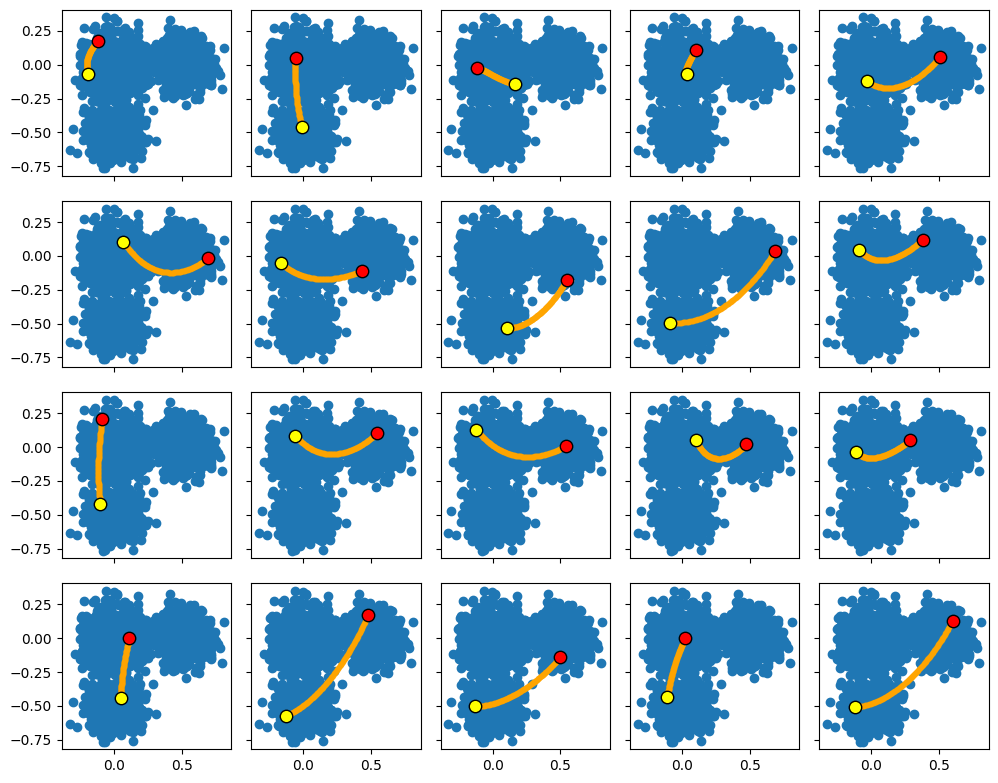

In [19]:
#GEO VALIDATION
for batch in train_dataloader:

    x0, x1, t0, t1 = batch
    print(x0.device)
    
    paths = embed_model.sample_geodesic_path(batch, num_points=200, ot_sample=False)

    break

fig, ax = plt.subplots(4, 5, figsize=(10, 8), sharex=True, sharey=True)

ax = ax.flatten()

for i in range(20):
    traj = paths[:,i]
    ax[i].scatter(samples[:,0], samples[:, 1])
    ax[i].plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
    ax[i].scatter(traj[0, 0], traj[0, 1], s=80, marker="o", color="red", edgecolor="black", zorder=3)
    ax[i].scatter(traj[-1, 0], traj[-1, 1], s=80, marker="o", color="yellow", edgecolor="black", zorder=3)

    ax[i].set(adjustable='box', aspect='equal')

plt.tight_layout() # Optional: adjusts spacing so labels don't overlap
plt.show()

In [20]:
#EMBED VALIDATION
if config.metric == "cfm" and not config.finsler.use:
    x0, x1, _, _= embed_model._prepare_batch(batch)
    x0, x1 = x0[0], x1[0]
    true_dist = torch.norm(x0 - x1, dim = -1)
    f = embed_model.embed_fn
    learned_dist = torch.norm(f(x0).detach() - f(x1).detach(), dim=-1)
    print(torch.stack([true_dist, learned_dist], dim=1)[:10])

/home/azweig/projects/finfm/models/embed_models.py:136: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(j)


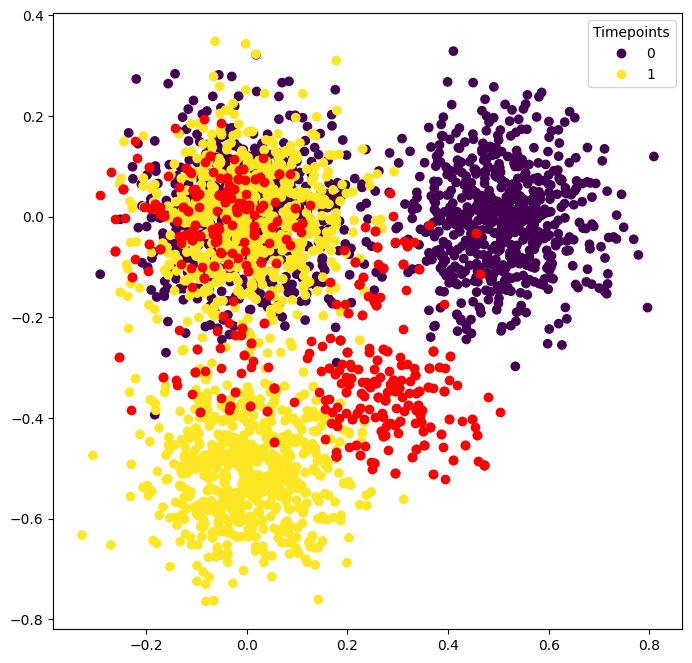

In [21]:
#GEO INTERPOLATION VALIDATION

t0 = 0
t = t0 + 0.5
t1 = t0 + 1

adata_prune = adata[adata.obs['timepoint'].isin([t0, t1])]
dataset = extract_paired_dataset(adata_prune)
train_dataset = ShufflingDataset(dataset, 512)
train_dataloader = DataLoader(train_dataset, batch_size = 1)

batch = next(iter(train_dataloader))
samples, weights = embed_model.sample_geodesic_time(batch, t, weighted = True)
weights = torch.softmax(weights, dim=0)
#TODO: weight?

true = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(1, figsize = (15, 8))
scatter0 = axs.scatter(true[:,0], true[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
handles, labels = scatter0.legend_elements()
axs.legend(handles, labels, title="Timepoints")
axs.scatter(samples[:,0], samples[:,1], c="red")
axs.set_aspect('equal')

plt.show()

torch.Size([200, 512, 2]) torch.Size([200, 512])
torch.Size([512])


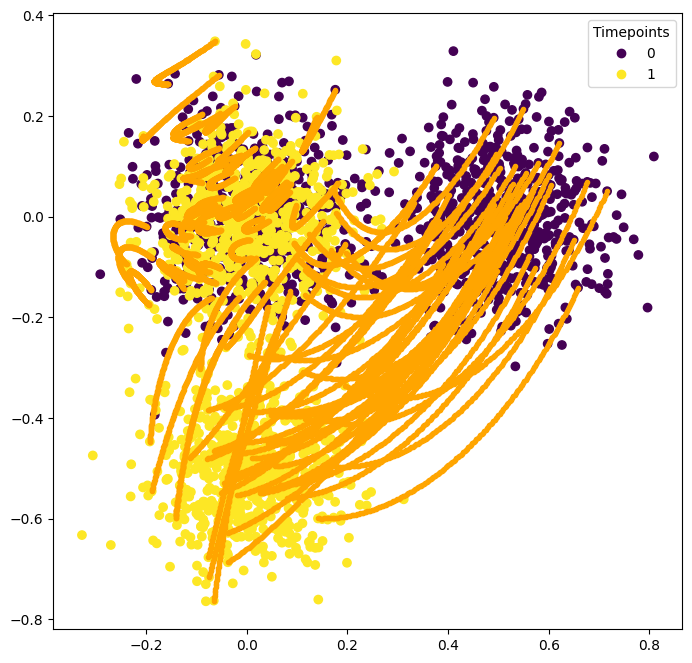

In [22]:
t0 = 0
t1 = 1

adata_prune = adata[adata.obs['timepoint'].isin([t0, t1])]
dataset = extract_paired_dataset(adata_prune)
train_dataset = ShufflingDataset(dataset, 512)
train_dataloader = DataLoader(train_dataset, batch_size = 1)


batch = next(iter(train_dataloader))
paths, weights = embed_model.sample_geodesic_path(batch, num_points=200, weighted=True)
print(paths.shape, weights.shape)
weights = torch.max(weights, dim = 0)[0]
weights = torch.softmax(weights, dim = 0)
min_val = torch.min(weights)
max_val = torch.max(weights)
weights = (weights - min_val) / (max_val - min_val)
print(weights.shape)
if config.method == "exact":
        weights = torch.ones_like(weights)

samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(1, figsize = (15, 8))
scatter0 = axs.scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
handles, labels = scatter0.legend_elements()
axs.legend(handles, labels, title="Timepoints")
for i in range(100):
        axs.plot(paths[:, i, 0], paths[:,i, 1], marker=".", linestyle="-", alpha=weights[i].item(), lw=1.5, color='orange')
axs.set_aspect('equal')

plt.show()

In [23]:
# #FLOW VALIDATION

# num_samples = 500
# steps = 500

In [24]:
# from datasets.dataset import sample
# def plot_flow(t0):
#     t1 = t0 + 1
#     x = adata[adata.obs['timepoint'].astype(int) == t0].obsm['X_pca']
#     x = sample(x, min(num_samples, x.shape[0]))
#     x = torch.from_numpy(x).float()
#     traj = flow_model.sample_traj(x, t0, t1, num_samples, steps=steps)
#     plot_trajectories(traj.cpu().numpy())

In [25]:
# x = [[-1, 0]]
# v = [[0, -1]]

# x = torch.tensor(x).float()
# v = torch.tensor(v).float()

# # metric_model(x, v)

# f_x, Jf_x_v = jvp(metric_model.classifier_fn, (x,), (v,))

# u = 1 - f_x @ (metric_model.tree.to(metric_model.get_device()) + torch.eye(f_x.shape[-1], device=x.device))

# # D = self.fisher_rao(x)
# D = torch.ones_like(f_x)

# finsler_term = torch.sum(Jf_x_v * D * u, dim=-1)
# finsler_term = F.relu(finsler_term)
# print(f_x)
# print(Jf_x_v)
# print(u)
# print(finsler_term)

In [26]:
# plot_flow(0)

In [27]:
# plot_flow(1)

In [28]:
# plot_flow(2)

In [29]:
# plot_flow(3)

In [30]:
# plot_flow(4)